![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 3. Interferometers I - MZI


Today we will work on the design and modeling of an **Mach-Zenhder Interferometer (MZI)** used in integrated photonic circuits. We will perform simulations that will allow us to understand how it operates.


## 0.1 General libraries

In [1]:
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

/tmp/ipykernel_24495/3896563056.py:10: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 1. MZI modeling
Let's compute the transfer function of a MZI

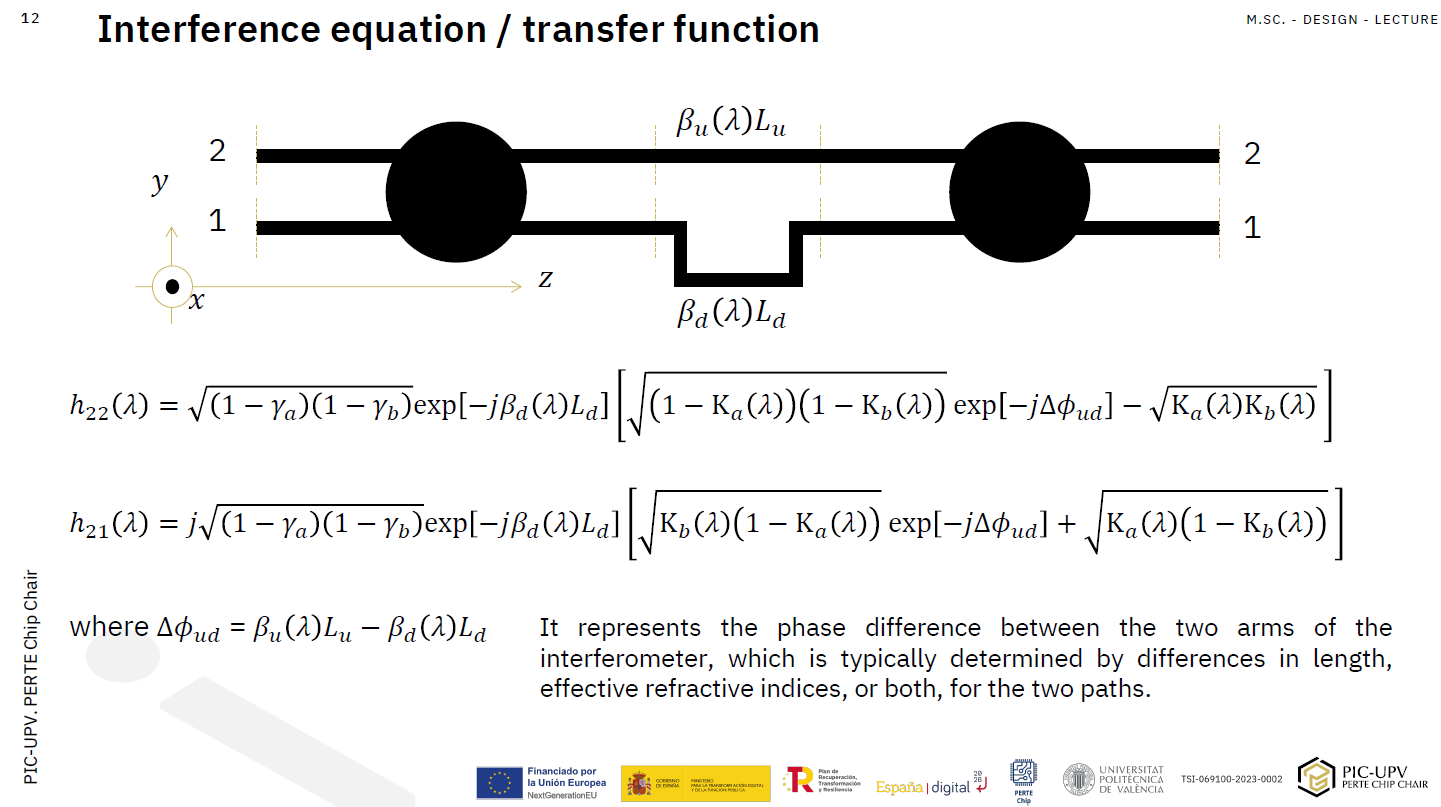

# Balanced

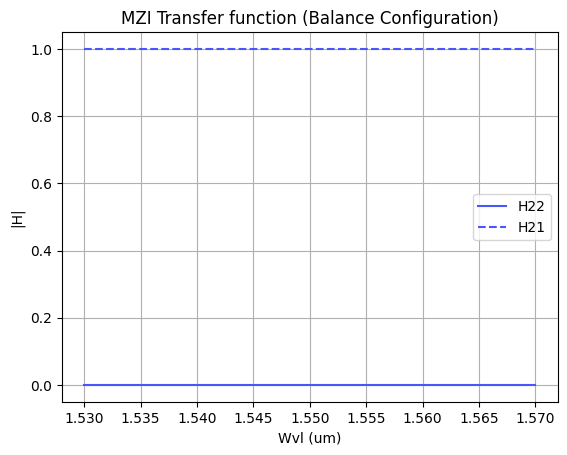

In [18]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Balance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

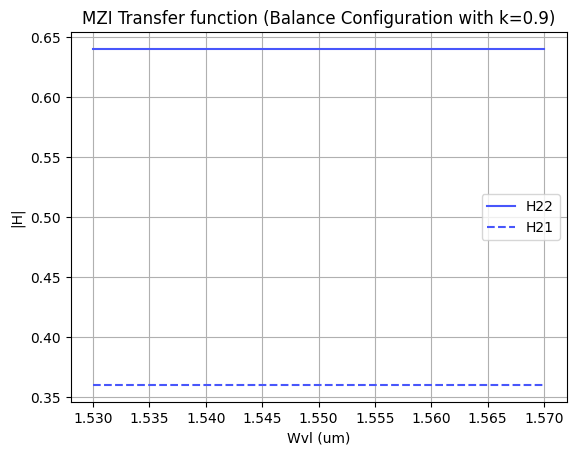

In [6]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.9)
K_b = np.full(wvl.shape, 0.9)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Balance Configuration with k=0.9)')
plt.legend()
plt.grid(True)

plt.show()

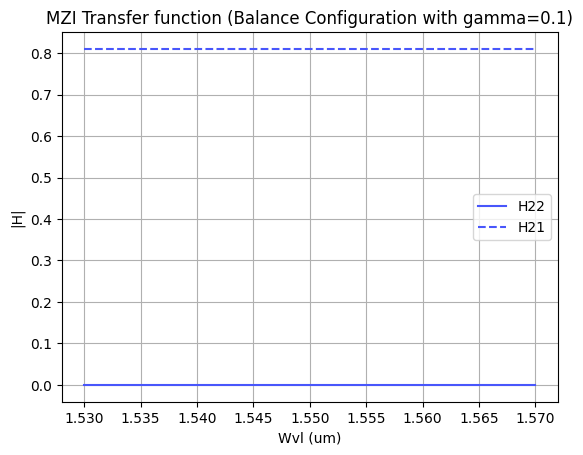

In [7]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0.1; #null excess loss
gamma_b = 0.1; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Balance Configuration with gamma=0.1)')
plt.legend()
plt.grid(True)

plt.show()

# Delay Imbalance

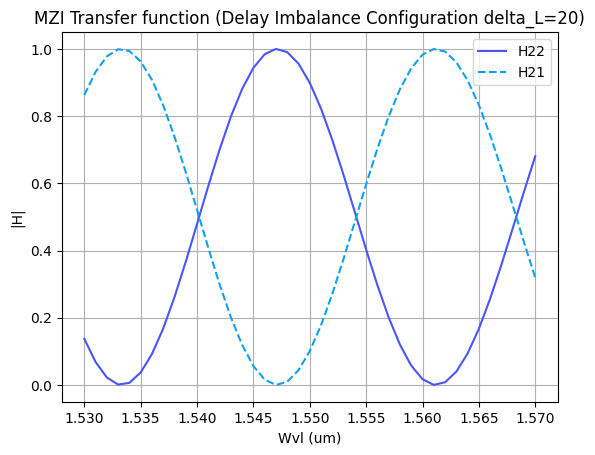

In [148]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Delay Imbalance Configuration delta_L=20)')
plt.legend()
plt.grid(True)

plt.show()

In [51]:
from scipy.signal import find_peaks


peaks, _ = find_peaks(H21)

peak_wvl = wvl[peaks]

print("Picos en:", peak_wvl)

fsr = np.diff(peak_wvl)

print("FSR entre picos:", fsr)

Picos en: [1.533 1.561]
FSR entre picos: [0.028]


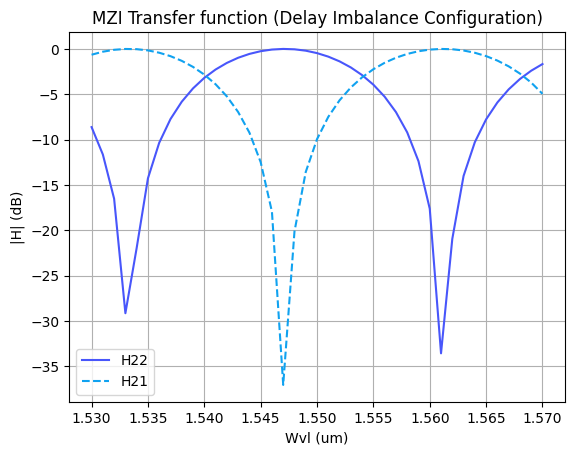

In [14]:
# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, 10*np.log10(H22), linestyle='-', color=color[1], label='H22')
plt.plot(wvl, 10*np.log10(H21), linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H| (dB)')
plt.title('MZI Transfer function (Delay Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

## 2.2.1

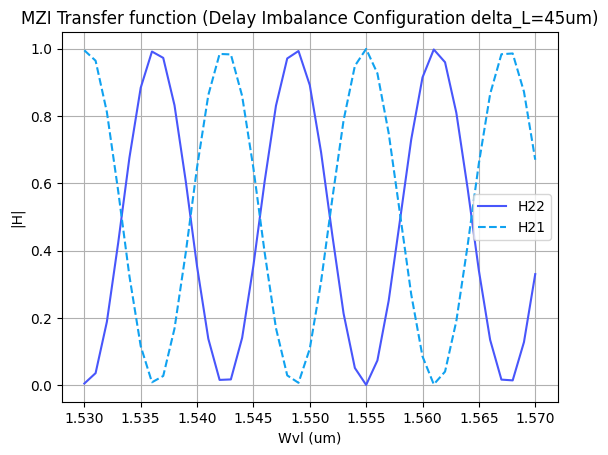

In [52]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 50; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Delay Imbalance Configuration delta_L=45um)')
plt.legend()
plt.grid(True)

plt.show()

In [53]:
peaks, _ = find_peaks(H21)

peak_wvl = wvl[peaks]

print("Picos en:", peak_wvl)

fsr = np.diff(peak_wvl)

print("FSR entre picos:", fsr)

Picos en: [1.542 1.555 1.568]
FSR entre picos: [0.013 0.013]


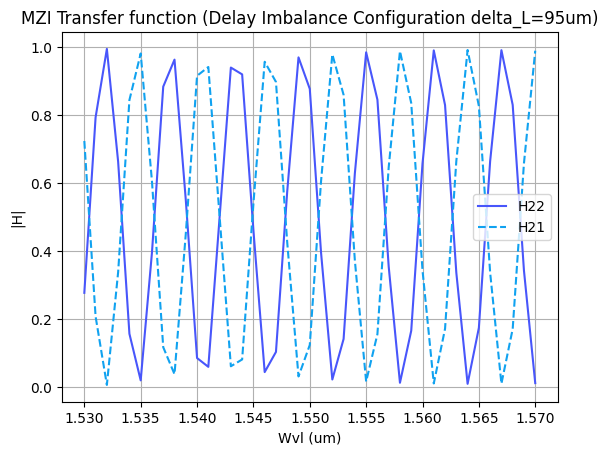

In [54]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 100; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Delay Imbalance Configuration delta_L=95um)')
plt.legend()
plt.grid(True)

plt.show()

In [55]:
peaks, _ = find_peaks(H21)

peak_wvl = wvl[peaks]

print("Picos en:", peak_wvl)

fsr = np.diff(peak_wvl)

print("FSR entre picos:", fsr)

Picos en: [1.535 1.541 1.546 1.552 1.558 1.564]
FSR entre picos: [0.006 0.005 0.006 0.006 0.006]


### 2.2.2 y 2.2.3 

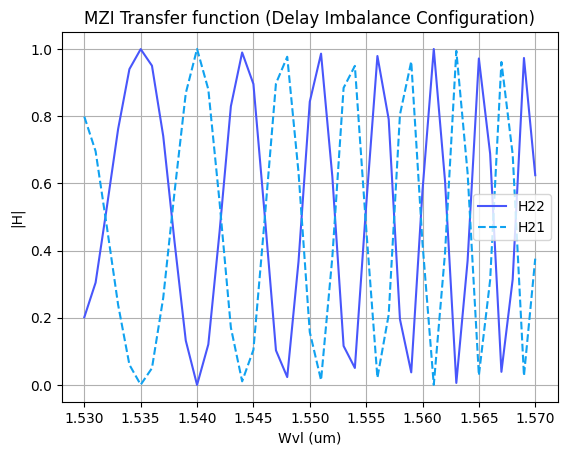

In [38]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = wvl**2*SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = wvl**2*SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 2000; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Delay Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

In [40]:
from scipy.signal import find_peaks


wl0 = 1.55 # longitud de onda central
FSR=40e-3
wvl = SOI[:, 0]

dn_dlambda = np.gradient(SOI[:, 3], wvl) #Hallo la pendiente para cada longitud de onda central
#print((2.35452-2.35702)/(1.551-1.549))
#i = np.argmin(np.abs(wvl - wl0)) # ubico el indice de la longitud de onda más cercana a la wl0
ng=[]
for i in range(0,len(wvl),1):
    ng.append(neffu[i] - wvl[i] * dn_dlambda[i])   # hallo el indice de grupo

print(f"indice de grupo en 1550 nm: {ng}")

peaks, _ = find_peaks(H22)

peak_wvl = wvl[peaks]

print("Picos en:", peak_wvl)

fsr = np.diff(peak_wvl)

print("FSR entre picos:", fsr)
print("Periodo espectral:", 1/fsr)

indice de grupo en 1550 nm: [np.float64(7.470274265999728), np.float64(7.483550199499833), np.float64(7.496809828000349), np.float64(7.502411553000346), np.float64(7.508010366999652), np.float64(7.50593126250018), np.float64(7.511542824960182), np.float64(7.524812891689999), np.float64(7.530400017440001), np.float64(7.53598419471035), np.float64(7.541565415999999), np.float64(7.54714367381), np.float64(7.552718960639649), np.float64(7.5505762689901825), np.float64(7.556164430720183), np.float64(7.5694507904999995), np.float64(7.575014149319649), np.float64(7.580574499680351), np.float64(7.5861318340800015), np.float64(7.5916861450203506), np.float64(7.597237425000001), np.float64(7.602785666519999), np.float64(7.608330862080001), np.float64(7.613873004180353), np.float64(7.6194120853200005), np.float64(7.624948098000353), np.float64(7.630481034719647), np.float64(7.6360108879799995), np.float64(7.64153765028), np.float64(7.64706131412), np.float64(7.6525818719996455), np.float64(7.6580

/tmp/ipykernel_3565/2164183894.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


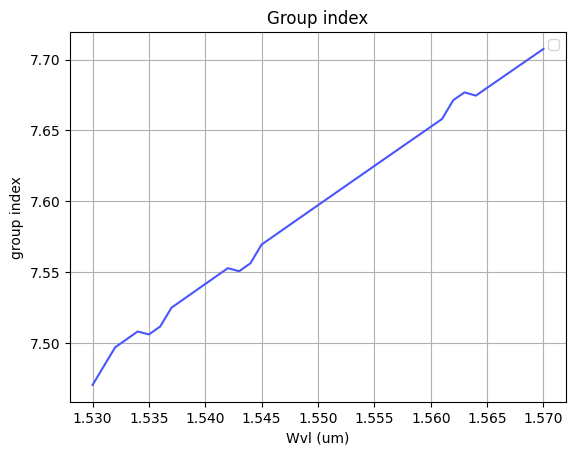

In [42]:
# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, ng, linestyle='-', color=color[1])
plt.xlabel('Wvl (um)')
plt.ylabel('group index')
plt.title('Group index')
plt.legend()
plt.grid(True)

plt.show()

## 2.1 Phase Imbalance

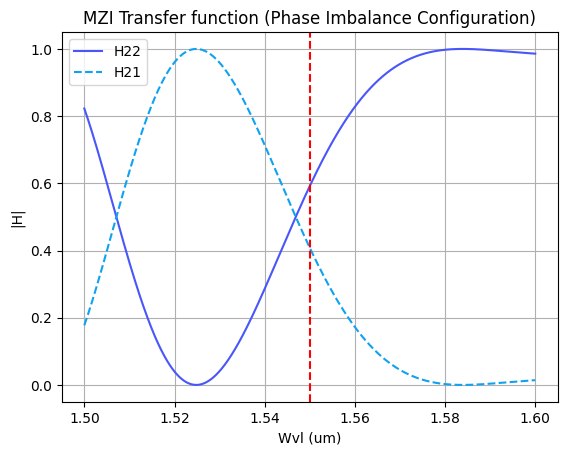

In [28]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
#SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 1000; # um
Ld = 1000; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.axvline(x=1.55, linestyle='--',color='r')
#plt.axhline(y=0.5, linestyle='--',color='r')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Phase Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

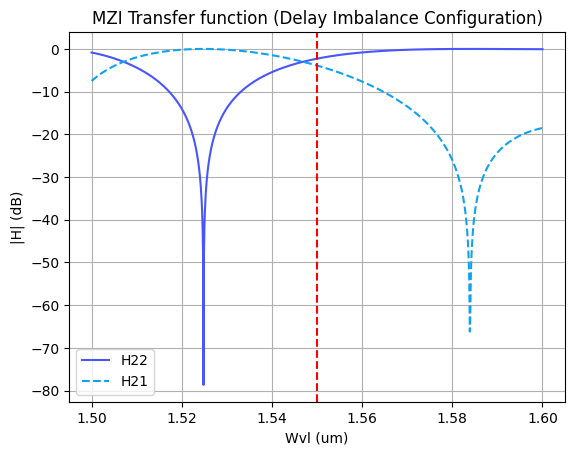

In [29]:
# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, 10*np.log10(H22), linestyle='-', color=color[1], label='H22')
plt.plot(wvl, 10*np.log10(H21), linestyle='--', color=color[2], label='H21')

plt.axvline(x=1.55, linestyle='--',color='r')
plt.xlabel('Wvl (um)')
plt.ylabel('|H| (dB)')
plt.title('MZI Transfer function (Delay Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

## 2.3 Amplitude Imbalance


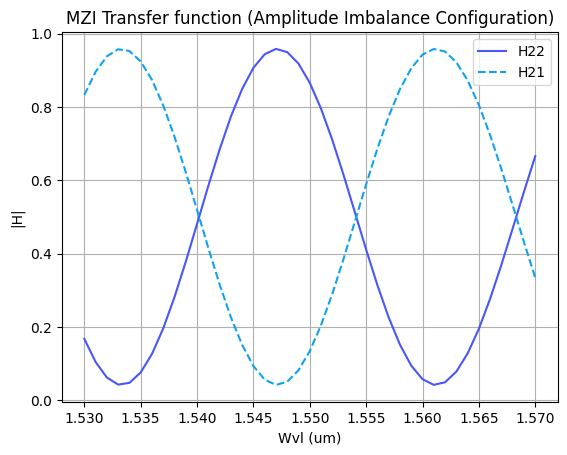

In [ ]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.3)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Amplitude Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

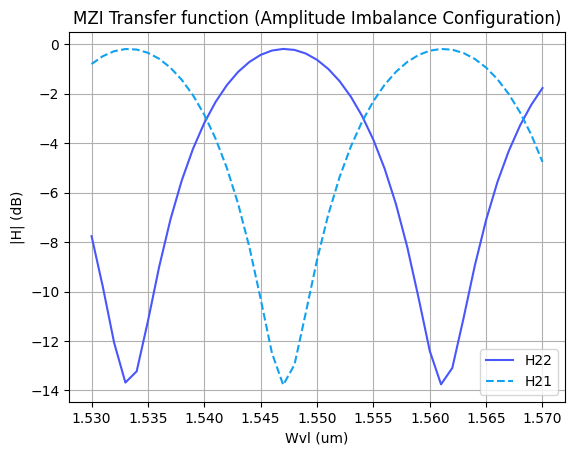

In [18]:
# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, 10*np.log10(H22), linestyle='-', color=color[1], label='H22')
plt.plot(wvl, 10*np.log10(H21), linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H| (dB)')
plt.title('MZI Transfer function (Amplitude Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

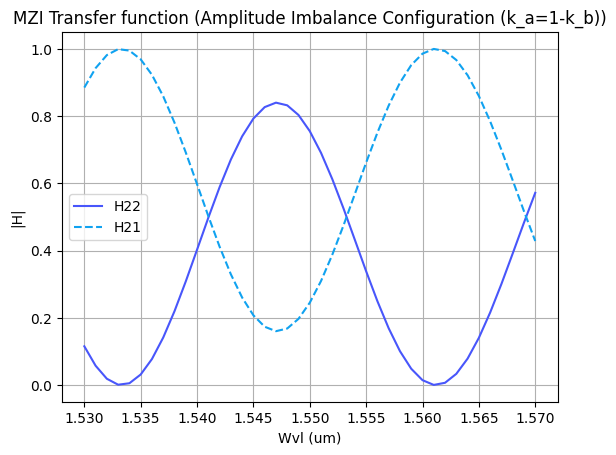

In [14]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.7)
K_b = np.full(wvl.shape, 0.3)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Amplitude Imbalance Configuration (k_a=1-k_b))')
plt.legend()
plt.grid(True)

plt.show()

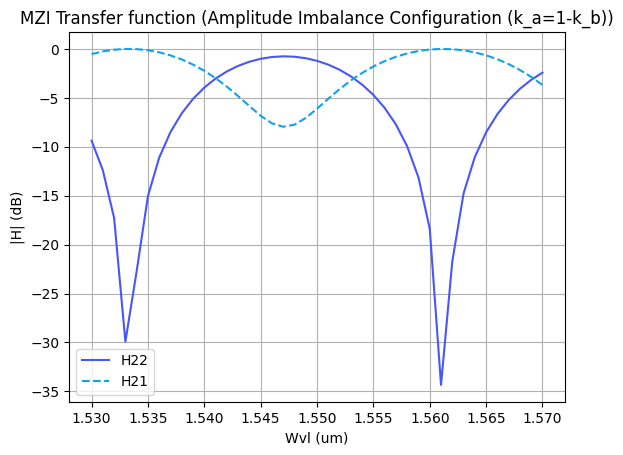

In [22]:
# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, 10*np.log10(H22), linestyle='-', color=color[1], label='H22')
plt.plot(wvl, 10*np.log10(H21), linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H| (dB)')
plt.title('MZI Transfer function (Amplitude Imbalance Configuration (k_a=1-k_b))')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 1.** Please, provide one example of each one of the configurations studied during MZI lecture:
1. Balenced configuration
2. Unbalanced configuration
  1.   Phase difference
  2.   Delay imbalance

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

# Assesment 2 Fress spectral range of 40 nm

In [151]:
import numpy as np
import scipy.constants as const

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wl0 = 1.55 # longitud de onda central
FSR=40e-3
wvl = SOI[:, 0]
n_eff=SOI[:,3]

dn_dlambda = np.gradient(SOI[:, 3], wvl) #Hallo la pendiente para cada longitud de onda central
#print((2.35452-2.35702)/(1.551-1.549))
i = np.argmin(np.abs(wvl - wl0)) # ubico el indice de la longitud de onda más cercana a la wl0
ng_1550 = n_eff[i] - wvl[i] * dn_dlambda[i] # hallo el indice de grupo

print(f"indice de grupo en 1550 nm: {ng_1550}")


deltaL=(wl0**2)/(FSR*ng_1550)

print(f"La diferencia de longitud de los caminos debe ser de: {deltaL} um")


indice de grupo en 1550 nm: 4.29327
La diferencia de longitud de los caminos debe ser de: 13.989919105949546 um


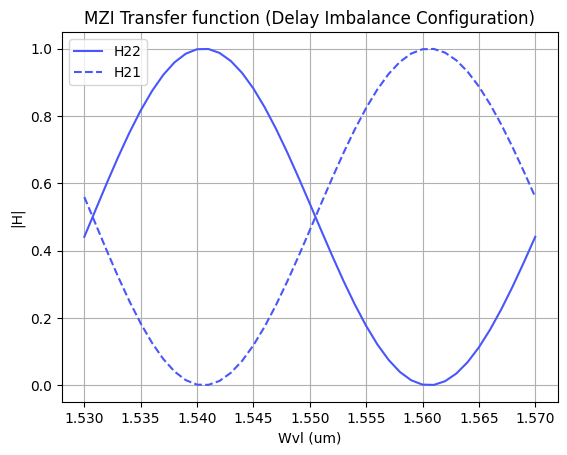

In [152]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25+deltaL; # um
Ld = 25; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Delay Imbalance Configuration)')
plt.legend()
plt.grid(True)

plt.show()

In [53]:
maxp=wvl[np.argmax(H22)]
minp=wvl[np.argmin(H22)]

FSR=2*(minp-maxp)

print(FSR)

0.040000000000000036


## 2. MZI simulation implemented with SAX
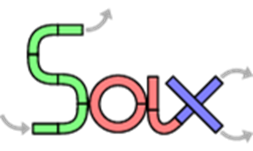

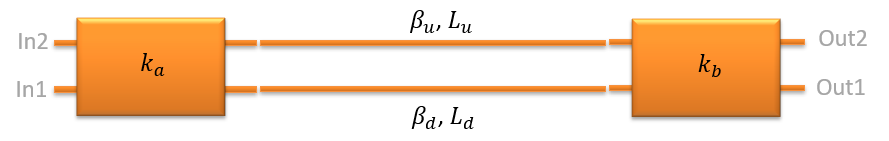


### 2.1 Components S matrix


In [12]:
# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 2.2 MZI SAX Circuit Model

In [13]:
# MZI

mzi, info = sax.circuit(
    netlist={
        "instances": {  # elementos que componen mi dispositivo y cual modelo le aplica
            "coup_a": "coupler",
            "wvg_u": "waveguide",
            "wvg_d": "waveguide",
            "coup_b": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",
            "wvg_d,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u,in0",
            "wvg_u,out0": "coup_b,in1",
        },
        "ports": { # a nivel global como son mis puertos 
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_b,out0",
            "out1": "coup_b,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


### 2.3. MZI Modeling
**Assesment 3**: Now, we are going to implement the design parameters in the MZI model developed in SAX and compare the response obtained with that simulated by mathematical formulation.

This will help us to identify any error in the definition of the SAX model single components.

In order to implement the SAX model, take as example the following lines:

    mzi_test = mzi(wl=wl,
                coup_a = ...
                wvg_d={"length": l_d, "neff": ...},
                wvg_u={"length": l_u, "neff": ...},
                coup_b = ... )

    H00 = mzi_test["in0", "out0"]


**Assessment 4.** Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.

**Assessment 5.** Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?

**Assessment 6.** Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.

# Assesment 3. MZI model developed in SAX

In [25]:
from scipy.signal import find_peaks

#Defino el metodo matematico en una función para luego solo llamarla y poder ver mejor la comparación
def mzi_math(neffu,neffd,wvl,alu,ald,longu,longd,gamA,gamB,kA,kB,hh):

    #neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
    #neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

    ## SiN cross-section ##
    #SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
    #SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

    #wvl0 = SiN_clad[:, 0]
    #neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
    #neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

    # interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
    # interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
    # wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
    # neffu = interp_neffu(wvl)
    # neffd = interp_neffd(wvl)

    # Propagation loss
    alphau = alu #losless case [dB/um]
    alphad = ald; #losless case [dB/um]
    alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
    alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

    # Path length
    Lu = longu; # um
    Ld = longd; # um

    betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
    betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

    Delta_phi_ud = betau*Lu - betad*Ld
    #print(Delta_phi_ud)

    ### Couplers configuration ###
    # Excess loss
    gamma_a = gamA; #null excess loss
    gamma_b = gamB; #null excess loss

    # Coupling constant
    K_a = np.full(wvl.shape, kA)
    K_b = np.full(wvl.shape, kB)

    # MZI transfer function (h22 & h21)

    #  h_22(wvl)
    h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

    #  h_21(wvl)
    h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

    H21 = np.abs(h_21) ** 2
    H22 = np.abs(h_22) ** 2
    if hh == 0:
        peaks, _ = find_peaks(H21)
        maxp=wvl[np.argmax(H21)]
        minp=wvl[np.argmin(H21)]
    else:
        peaks, _ = find_peaks(H22)
        maxp=wvl[np.argmax(H22)]
        minp=wvl[np.argmin(H22)]

    peak_wvl = wvl[peaks]
    fsr = np.diff(peak_wvl)
    print("FSR entre picos:", fsr)

    

    FSR=2*np.abs((minp-maxp))

    print(f"el FSR2 es de: {FSR} um")

    # Plot
    color = cm.rainbow(np.linspace(0, 1, 10))

    plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
    plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
    plt.xlabel('Wvl (um)')
    plt.ylabel('|H|')
    plt.title('MZI Transfer function (mathematical method)')
    plt.legend()
    plt.grid(True)

    plt.show()

In [15]:
#Parámetros

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

# Path length
Lu = 25; # um
Ld = 5; # um

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

el FSR es de: 0.028000000000000025 um


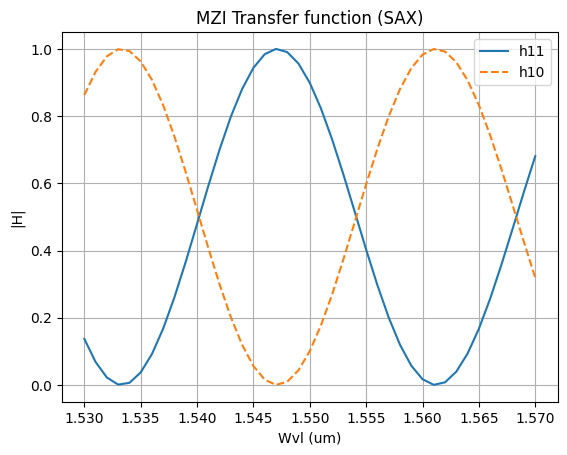

In [16]:
mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": 5, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": 25, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]
H11=np.abs(h11)**2

maxp=wvl[np.argmax(H11)]
minp=wvl[np.argmin(H11)]

FSR=2*(minp-maxp)

print(f"el FSR es de: {FSR} um")


# Plot
plt.figure()
plt.plot(wvl, H11, linestyle="-", label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", label=f"h10")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function (SAX)')
plt.grid(True)
plt.show()


FSR entre picos: []
el FSR2 es de: 0.028000000000000025 um


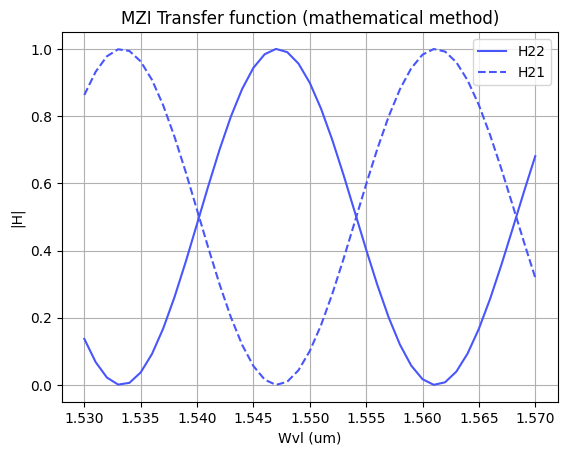

In [20]:
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]   
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)


mzi_math(neffu,neffd,wvl,0,0,5,25,0,0,0.5,0.5,1)

### Assessment 4 

Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.

Buscamos que para una de las salidas tengamos la mayor interferencia constructiva para ello la diferencia en fase debe ser 

delta_phase=2*pi*m

ademas, si recordamos que la fase viene dada por:

delta_phase=beta*delta_L/2=pi*neff*delta_L/Lambda

igualando

pi*neff*delta_L/Lambda=2*pi*m

Despejando cual debe ser la diferencia entre los brazos:

delta_L=2*pi*m*lambda/(pi*neff)=2*m*lambda/neff

tomando un m=10

delta_L=20*lambda/neff

In [101]:
#Definir los parámetros de los MZI 

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)


# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

wl0 = 1.55
wvl = SOI[:, 0]
neff = SOI[:,3]
i = np.argmin(np.abs(wvl - wl0))

neff_1550=neff[i]

m=10
delta_L=2*m*wl0/neff_1550

L_1=5
L_2=L_1+delta_L

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

print(delta_L)
print(L_1)
print(L_2)

13.159179376594489
5
18.159179376594487


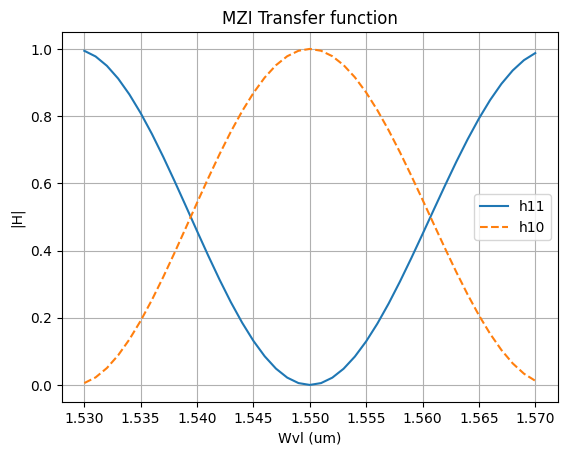

In [102]:
mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": L_1, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": L_2, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]

# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", label=f"h10")
#plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
#plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

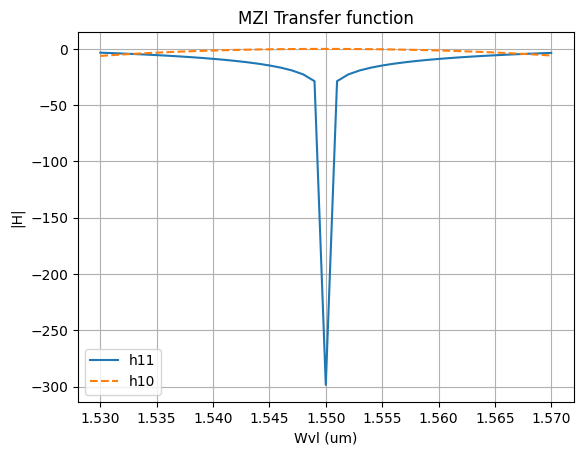

In [100]:
# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(h11)**2), linestyle="-", label=f"h11")
plt.plot(wvl, 10*np.log(np.abs(h10)**2), linestyle="--", label=f"h10")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

# Assesment 5

In [21]:

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)


FSR entre picos: [0.04514515]
el FSR2 es de: 0.046046046046045674 um


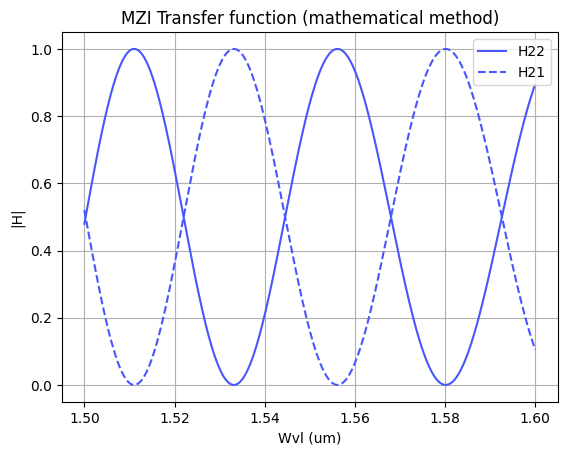

In [27]:
mzi_math(neffu,neffd,wvl,0,0,2000,2000,0,0,0.5,0.5,1)

In [30]:

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)


FSR entre picos: [0.03973974]
el FSR2 es de: 0.03543543543543537 um


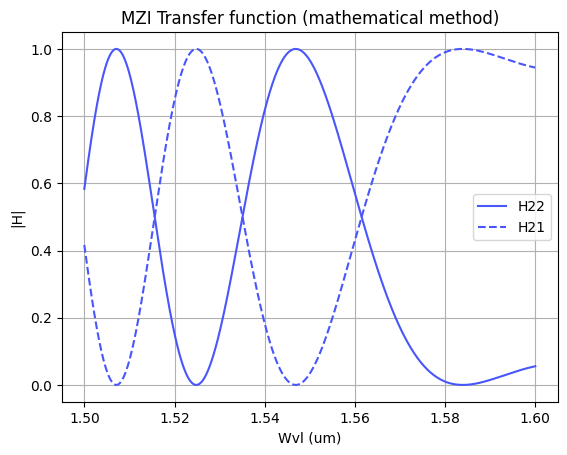

In [31]:
mzi_math(neffu,neffd,wvl,0,0,2000,2000,0,0,0.5,0.5,1)

In [40]:

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_wat[:, 0]
neffu0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)


FSR entre picos: [0.03933934 0.01841842]
1.595895895895896
1.512012012012012
el FSR2 es de: 0.16776776776776803 um


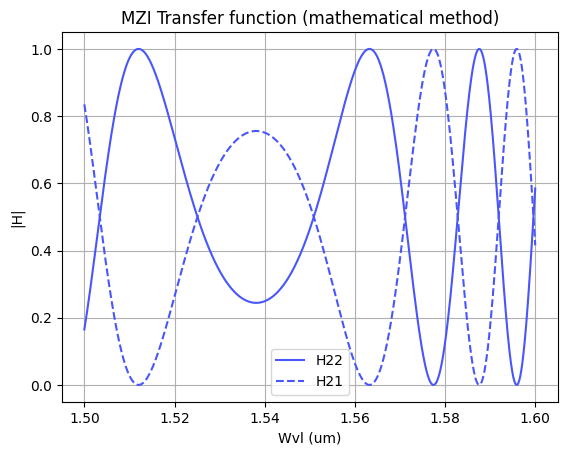

In [43]:
mzi_math(neffu,neffd,wvl,0,0,8000,8000,0,0,0.5,0.5,0)

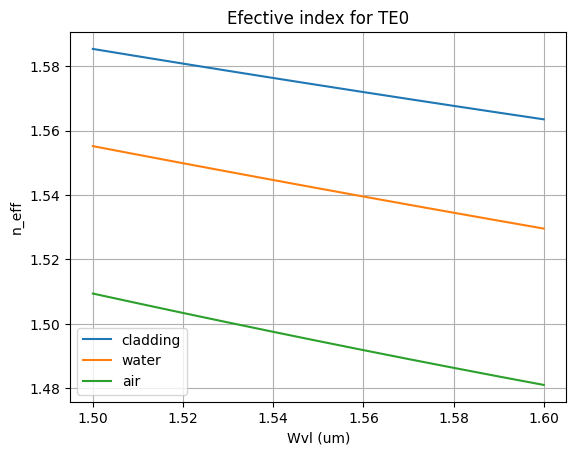

In [50]:
plt.figure()

plt.plot(wvl0, SiN_clad[:, 3], linestyle="-", label=f"cladding")
plt.plot(wvl0, SiN_wat[:, 3], linestyle="-", label="water")
plt.plot(wvl0, SiN_air[:, 3], linestyle="-", label=f"air")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('n_eff')
plt.title('Efective index for TE0')
plt.grid(True)
plt.show()

### Assessment 6.

In [33]:
# MZI
mzi, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u": "waveguide",
            "wvg_d": "waveguide",
            "coup_b": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",
            "wvg_d,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u,in0",
            "wvg_u,out0": "coup_b,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_b,out0",
            "out1": "coup_b,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

In [34]:
# MZI

mziCasc, info = sax.circuit(
    netlist={
        "instances": {  # elementos que componen mi dispositivo y cual modelo le aplica
            "mzi_a": "mzi",
            "mzi_b": "mzi",
        },
        "connections": {
            "mzi_a,out0": "mzi_b,in0",
            "mzi_a,out1": "mzi_b,in1",
        },
        "ports": { # a nivel global como son mis puertos 
            "in0": "mzi_a,in0",
            "in1": "mzi_a,in1",
            "out0": "mzi_b,out0",
            "out1": "mzi_b,out1",
        },
    },
    models={
        "mzi": mzi,
    },
)

In [53]:
#Definir los parámetros de los MZI 

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)


# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]

# Path length
Lu1 = 5; # um
Ld1 = 25; # um

# Path length
Lu2 = 25; # um
Ld2 = 5; # um


betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)



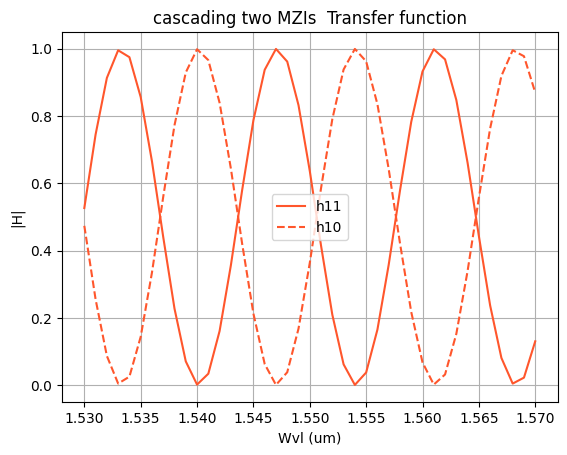

In [54]:
mzi_cascada_test = mziCasc(
    mzi_a={
        "coup_a": {"coupling": K_a},
        "wvg_u": {"wl": wvl, "neff": neffu, "length": Lu1, "loss": alphau},
        "wvg_d": {"wl": wvl, "neff": neffd, "length": Ld1, "loss": alphad},
        "coup_b": {"coupling": K_b},
    },
    mzi_b={
        "coup_a": {"coupling": K_a},
        "wvg_u": {"wl": wvl, "neff": neffu, "length": Lu2, "loss": alphau},
        "wvg_d": {"wl": wvl, "neff": neffd, "length": Ld2, "loss": alphad},
        "coup_b": {"coupling": K_b},
    },
)

h00 = mzi_cascada_test["in0", "out0"]
h01 = mzi_cascada_test["in0", "out1"]
h11 = mzi_cascada_test["in1", "out1"]
h10 = mzi_cascada_test["in1", "out0"]


# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", color=color[8], label=f"h10")
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('cascading two MZIs  Transfer function')
plt.legend()
plt.grid(True)
plt.show()


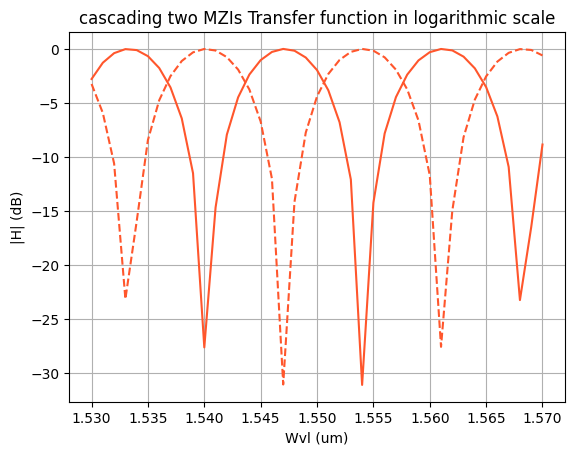

In [43]:

# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(h11)**2), linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, 10*np.log10(np.abs(h10)**2), linestyle="--", color=color[8], label=f"h10")
plt.xlabel('Wvl (um)')
plt.ylabel('|H| (dB)')
plt.title('cascading two MZIs Transfer function in logarithmic scale')
plt.grid(True)
plt.show()


In [41]:
from scipy.signal import find_peaks


peaks, _ = find_peaks(h11)

peak_wvl = wvl[peaks]

print("Picos en:", peak_wvl)

fsr = np.diff(peak_wvl)

print("FSR entre picos:", fsr)

Picos en: [1.533 1.544 1.555 1.567]
FSR entre picos: [0.011 0.011 0.012]


/home/au/pic-upv-lab3_copy/.venv/lib/python3.12/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


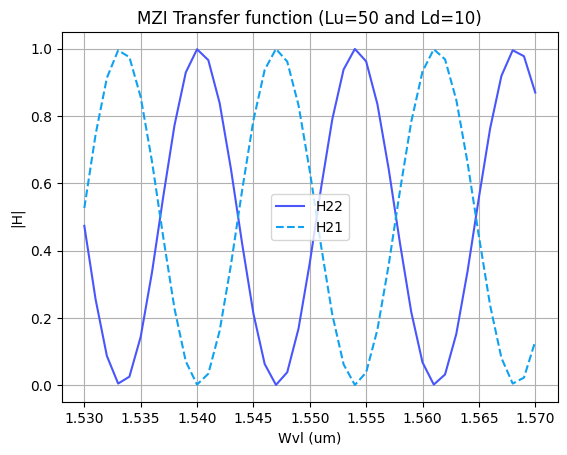

In [45]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

#wvl0 = SiN_clad[:, 0]
#neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
#neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (jnp.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (jnp.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 50; # um
Ld = 10; # um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld
#print(Delta_phi_ud)

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function (Lu=50 and Ld=10)')
plt.legend()
plt.grid(True)

plt.show()